## SNAP or Not - The Same Foods In Every American Grocery Cart


 ## Setup and Data Loading
The following analysis uses the USDA's 2016 study, "Foods Typically Purchased by SNAP Households," which compares grocery spending patterns between SNAP and non-SNAP households using 2011 point-of-sale data from a single retailer. I begin by importing necessary libraries and loading a cleaned version of the
dataset, which I sourced from the Data Is Plural archive.

In [1]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/commodities-spending.csv")

In [3]:
df

,commodity,snap_rank,snap_spending,snap_pct_of_total,nonsnap_rank,nonsnap_spending,nonsnap_pct_of_total
0,Soft drinks,1,357.7,5.44,2,1263.3,4.01
1,Fluid milk products,2,253.7,3.85,1,1270.3,4.03
2,Beef:grinds,3,201.0,3.05,6,621.1,1.97
3,Bag snacks,4,199.3,3.03,5,793.9,2.52
4,Cheese,5,186.4,2.83,3,948.9,3.01
...,...,...,...,...,...,...,...
233,Authentic italian foods,234,0.5,0.01,216,7.4,0.02
234,Bakery party trays,235,0.4,0.01,236,1.9,0.01
235,Candy,236,0.4,0.01,220,6.5,0.02
236,Authentic caribbean foods,237,0.4,0.01,238,1.1,0.00


## Initial Data Analysis

After loading the dataset, my first step is to understand the data at hand and conudct data cleaning, if it is needed. This incudes finding the size of the dataset, key statistics, as well as what each feature means.

In [4]:
df.shape

(238, 7)

In [5]:
df.isnull().sum()

,0
commodity,0
snap_rank,0
snap_spending,0
snap_pct_of_total,0
nonsnap_rank,0
nonsnap_spending,0
nonsnap_pct_of_total,0


In [6]:
df['commodity'].unique() # Here I looked at what commodities are included in the dataset

array(['Soft drinks', 'Fluid milk products', 'Beef:grinds', 'Bag snacks',
       'Cheese', 'Baked breads', 'Cold cereal', 'Chicken fresh',
       'Frozen handhelds & snacks', 'Lunchmeat', 'Candy\xa0‐\xa0packaged',
       'Infant formula', 'Frozen pizza', 'Refrigerated juices/drinks',
       'Ice cream ice milk & sherbets', 'Coffee & creamers', 'Cookies',
       'Water\xa0‐\xa0(sparkling & still)', 'Shelf stable juice',
       'Eggs/muffins/potatoes', 'Frozen ss premium meals', 'Cakes',
       'Bacon', 'Traditional Mexican foods', 'Yogurt',
       'Salad dressing & sandwich spreads', 'Dinner sausage',
       'Frozen prepared chicken', 'Baked sweet goods', 'Beef loins',
       'Chicken frozen', 'Deli meat: bulk', 'Frozen multi serve',
       'Dinner mixes‐dry', 'Frozen breakfast foods',
       'Crackers & misc baked food', 'Frozen novelties‐water ice',
       'Margarines', 'Condiments & sauces', 'Potatoes',
       'Frozen vegetable & veg dish', 'Hot dogs',
       'Can vegetables\xa0‐\xa0

When analyzing the differnt types of commodities in the dataset, I realized some included "\xa0" chracters, so I cleaned the data by replacing them with a space.

In [7]:
df["commodity"] = df["commodity"].str.replace("\xa0", " ", regex=False)
# df['commodity'].unique()

To get a better understanding of how spending is distributed across all 238
commodities, I used the .describe() function. I noticed that average spending per commodity differs sharply between SNAP and non-SNAP households (\$27.65M vs. \$132.41M), which mostly proves that non-SNAP households have a much larger total spending pool.

 I also noticed that for both groups, the mean is a lot higher than the median (\$13.80M for SNAP, \$72.55M for non-SNAP), likely indicating a right-skewed distribution, where a small number of commodities are pulling the average up, while most commodities are at lower spending levels.

In [8]:
df.describe()


,snap_rank,snap_spending,snap_pct_of_total,nonsnap_rank,nonsnap_spending,nonsnap_pct_of_total
count,238.000000,238.000000,238.00000,238.000000,238.000000,238.000000
mean,119.500000,27.651261,0.42021,119.500000,132.409664,0.420336
std,68.848868,41.932859,0.63724,68.848868,181.369232,0.575605
min,1.000000,0.400000,0.01000,1.000000,1.100000,0.000000
25%,60.250000,3.225000,0.05000,60.250000,25.450000,0.080000
50%,119.500000,13.800000,0.21000,119.500000,72.550000,0.230000
75%,178.750000,36.075000,0.55000,178.750000,161.825000,0.517500
max,238.000000,357.700000,5.44000,238.000000,1270.300000,4.030000



Since the describe function shows that spending is concentrated in a relatively small set of
top commodities rather than spread evenly across all 238,  I decided to
focus the next stage of this analysis on the top 10 ranked commodities for both SNAP and non-SNAP households.

In [9]:
top_ten_snap = df.sort_values("snap_rank").head(10)
print("Top 10 commodities — SNAP households")
top_ten_snap

Top 10 commodities — SNAP households


,commodity,snap_rank,snap_spending,snap_pct_of_total,nonsnap_rank,nonsnap_spending,nonsnap_pct_of_total
0,Soft drinks,1,357.7,5.44,2,1263.3,4.01
1,Fluid milk products,2,253.7,3.85,1,1270.3,4.03
2,Beef:grinds,3,201.0,3.05,6,621.1,1.97
3,Bag snacks,4,199.3,3.03,5,793.9,2.52
4,Cheese,5,186.4,2.83,3,948.9,3.01
5,Baked breads,6,163.7,2.49,4,874.8,2.78
6,Cold cereal,7,139.2,2.12,7,583.9,1.85
7,Chicken fresh,8,121.4,1.85,11,477.8,1.52
8,Frozen handhelds & snacks,9,101.5,1.54,47,214.6,0.68
9,Lunchmeat,10,99.4,1.51,17,386.1,1.23


In [10]:
top_ten_nonsnap = df.sort_values("nonsnap_rank").head(10)
print("\nTop 10 commodities — non-SNAP households")
top_ten_nonsnap


Top 10 commodities — non-SNAP households


,commodity,snap_rank,snap_spending,snap_pct_of_total,nonsnap_rank,nonsnap_spending,nonsnap_pct_of_total
1,Fluid milk products,2,253.7,3.85,1,1270.3,4.03
0,Soft drinks,1,357.7,5.44,2,1263.3,4.01
4,Cheese,5,186.4,2.83,3,948.9,3.01
5,Baked breads,6,163.7,2.49,4,874.8,2.78
3,Bag snacks,4,199.3,3.03,5,793.9,2.52
2,Beef:grinds,3,201.0,3.05,6,621.1,1.97
6,Cold cereal,7,139.2,2.12,7,583.9,1.85
10,Candy ‐ packaged,11,96.2,1.46,8,527.7,1.67
15,Coffee & creamers,16,82.3,1.25,9,519.4,1.65
14,Ice cream ice milk & sherbets,15,86.0,1.31,10,481.8,1.53


The two tables above show that SNAP and non-SNAP households share many of the same
top 10 commodities, including soft drinks, fluid milk products, and cheese. The most
interesting difference was that non-SNAP households' top 10 included more unhealthy
items, such as ice cream, coffee creamer, and candy, while SNAP households' top 10 leaned
slightly more toward staples like chicken and lunchmeat. Since most of the top 10 was
still similar between groups, I wanted to see where commodities diverge the most in
rank across the full dataset, not just the top 10.

In [11]:
df["rank_gap"] = df["nonsnap_rank"] - df["snap_rank"]
commodity_gap = df.sort_values("rank_gap", ascending=False)

print("Commodities households prioritize differently:")
commodity_gap

Commodities households prioritize differently:


,commodity,snap_rank,snap_spending,snap_pct_of_total,nonsnap_rank,nonsnap_spending,nonsnap_pct_of_total,rank_gap
11,Infant formula,12,95.7,1.45,80,124.8,0.40,68
50,Frozen ss economy meals,51,40.9,0.62,109,80.7,0.26,58
175,Pork offal,176,3.5,0.05,232,4.2,0.01,56
134,Seafood – catfish,135,9.8,0.15,191,17.6,0.06,56
30,Chicken frozen,31,54.8,0.83,85,123.0,0.39,54
...,...,...,...,...,...,...,...,...
174,Cereals,175,3.8,0.06,131,63.0,0.20,-44
101,Bread,102,18.7,0.28,49,194.7,0.62,-53
157,Fitness & diet,158,5.8,0.09,101,95.8,0.30,-57
136,Specialty cheese pre pack,137,9.6,0.15,67,152.4,0.48,-70



The commodities with the largest positive rank_gap are ranked higher by SNAP households and are mostly frozen meals, protiens, and valuable items like infant formula. The commodities with the largest negative rank_gap are ranked higher by non-SNAP households and seem to be more specialty items like pre-packed cheese and dairy cases.

Rather than SNAP households leaning
toward "junk food" more than non-SNAP households, this wider view shows that SNAP households relatively prioritize affordable, shelf-stable,
and pre-prepared staples more than non-SNAP households do. However, it is worth noting these are not high-spending categories overall, as most account for under 1.5% of total spending in either group.


# Part 4: Visualizations

The following visual shows the top 10 commodities by % of total spending for SNAP households. Soft drinks are the single largest category at 5.44% of all SNAP spending, followed closely by fluid milk products (3.85%) and beef:grinds (3.05%). Percetages can be seen in the top_ten_snap table above.

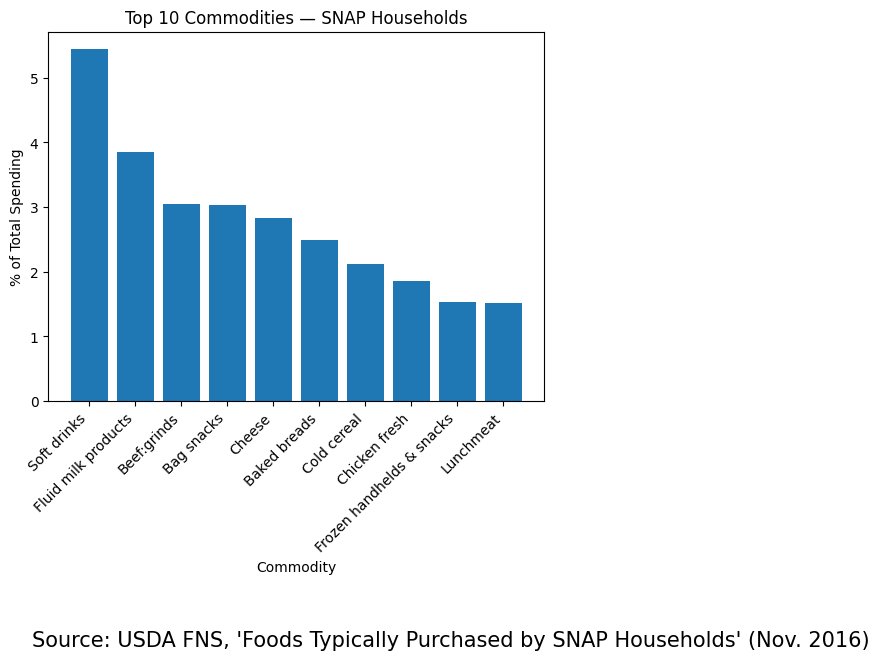

In [12]:
plt.bar(top_ten_snap["commodity"], top_ten_snap["snap_pct_of_total"])
plt.title("Top 10 Commodities — SNAP Households")
plt.ylabel("% of Total Spending")
plt.xlabel("Commodity")
plt.xticks(rotation=45, ha="right");
plt.figtext(0.1, -0.40,
"Source: USDA FNS, 'Foods Typically Purchased by SNAP Households' (Nov. 2016)",
            fontsize=15);

The following barchart shows the same measure for non-SNAP households. The same core
commodities dominate here too , fluid milk products lead at 4.03%, with soft drinks
close behind at 4.01%.

Comparing the two charts side by side, 7 of the top 10 commodities are identical
between non-SNAP and SNAP groups,  supporting this project's central finding: SNAP and
non-SNAP households prioritize largely the same groceries, with only small
differences in ranking.


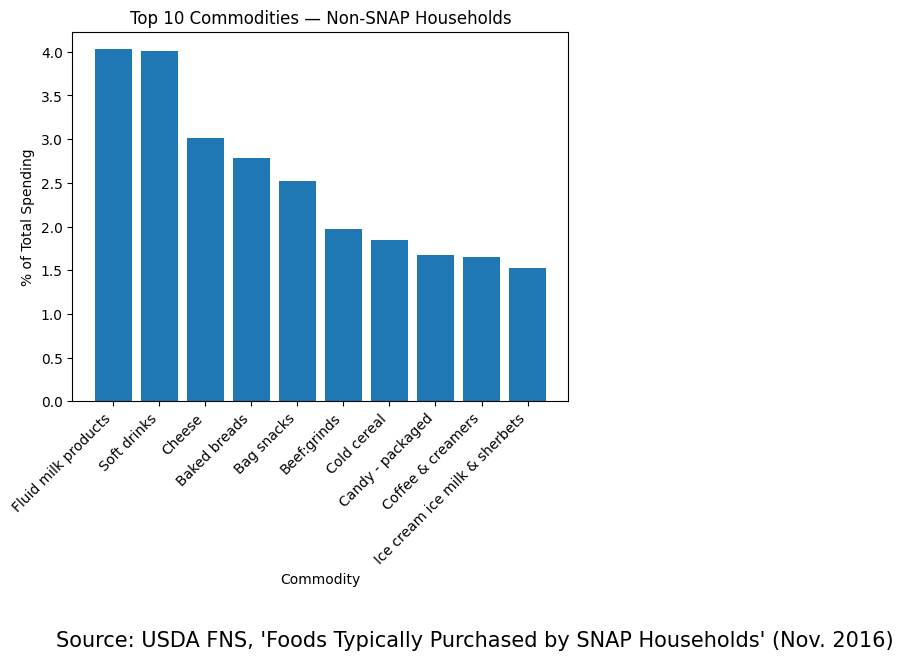

In [13]:
plt.bar(top_ten_nonsnap["commodity"], top_ten_nonsnap["nonsnap_pct_of_total"])
plt.title("Top 10 Commodities — Non-SNAP Households")
plt.ylabel("% of Total Spending")
plt.xlabel("Commodity")
plt.xticks(rotation=45, ha="right")
plt.figtext(0.1, -0.40,
 "Source: USDA FNS, 'Foods Typically Purchased by SNAP Households' (Nov. 2016)",
            fontsize=15);